In [1]:
!pip install python-chess timm einops pillow tqdm -q

In [2]:
# ============================================================
# LeWorldModel Chess Engine — Final A100 Implementation
# ============================================================
# Based on: "LeWorldModel: Stable End-to-End JEPA from Pixels"
# Paper:   https://arxiv.org/pdf/2603.19312
# Code:    https://github.com/lucas-maes/le-wm
#
# Architecture from the paper (§3.1, Appendix D):
#   - Encoder: ViT-Tiny (patch=14, 12 layers, 3 heads, dim=192)
#   - Projector: 1-layer MLP + BatchNorm (removes LayerNorm effect)
#   - Predictor: 6-layer Transformer, 16 heads, AdaLN-zero conditioning
#   - Loss: ℒ_pred (MSE, teacher-forced) + λ·SIGReg (Gaussian prior)
#
# Chess adaptations:
#   - Board rendered as 128×128 RGB with piece-type-specific colors
#     → patch_size=16 gives exactly 64 tokens (1 per square)
#   - Discrete move embedder replaces continuous action Conv1d
#   - CEM planner adapted for legal-move-constrained discrete search
#   - Optional policy head for fast move prediction
#
# Hardware target: NVIDIA A100 (40/80 GB)
# ============================================================


# %% ── CELL 1: Install dependencies ──────────────────────────
# !pip install python-chess timm einops pillow tqdm -q


# %% ── CELL 2: Imports & config ──────────────────────────────

import chess
import chess.pgn
import io
import math
import os
import random
import time
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from PIL import Image, ImageDraw
from einops import rearrange
from tqdm import tqdm
import timm

# ── A100 optimizations ──
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


@dataclass
class Config:
    """
    Hyperparameters aligned with the paper (Appendix D + G ablations).
    Tuned for A100 with chess-specific adaptations.
    """
    # ── File paths ──
    pgn_path: str = "Gukesh.pgn"
    cache_path: str = "dataset_game_v2.pt"  # Full-game trajectory cache

    # ── Data ──
    img_size: int = 128
    patch_size: int = 16
    frame_skip: int = 2           # Every full move
    seq_len: int = 20             # 20-frame windows from full games
    history_size: int = 16        # 16 positions of context (~16 full moves)
    num_preds: int = 4            # Predict 4 steps ahead (strategic)
    val_split: float = 0.1

    # ── Model (ViT-Tiny, paper §3.1) ──
    embed_dim: int = 192          # Paper: 192 (ablation: ≥184 needed)
    hidden_dim: int = 192         # ViT-Tiny hidden dim

    # ── Move vocabulary ──
    n_move_vocab: int = 4352      # 64×64 from-to + 256 promotion slots
    move_embed_dim: int = 64      # Intermediate move embedding

    # ── Predictor (paper: ViT-S backbone, 6 layers, 16 heads) ──
    pred_depth: int = 6           # Paper: 6 (ablation: ViT-S optimal)
    pred_heads: int = 16          # Paper: 16
    pred_mlp_dim: int = 2048      # Paper: 2048 (4× hidden)
    pred_dim_head: int = 64
    pred_dropout: float = 0.1     # Paper: 0.1 (ablation: critical)
    pred_emb_dropout: float = 0.0

    # ── SIGReg (paper §3.1, Appendix A & G) ──
    # Paper ablation (Fig 16): λ∈[0.01, 0.2] all achieve >80% success.
    # We use 0.09 (paper default) with warmup to handle high initial values.
    sigreg_knots: int = 17        # Integration nodes  (repo: 17)
    sigreg_num_proj: int = 1024   # Random projections (repo: 1024)
    sigreg_lambda: float = 0.09   # λ (paper: 0.09)
    sigreg_warmup_epochs: int = 0 # 0 = fixed λ from epoch 0 (paper default, CRITICAL)

    # ── Training ──
    batch_size: int = 128         # Reduced: seq_len=20 → 5x more ViT calls per batch
    lr: float = 1e-4
    weight_decay: float = 1e-3
    epochs: int = 40              # More epochs to compensate smaller batch
    warmup_epochs: int = 3
    grad_clip: float = 5.0
    precision: str = "bf16"
    log_every: int = 50
    compile_model: bool = True

    # ── Auxiliary heads ──
    use_policy_head: bool = True
    policy_loss_weight: float = 0.1
    use_value_head: bool = True   # NEW: predict game outcome from embedding
    value_loss_weight: float = 0.05
    use_game_progress: bool = True  # NEW: condition on move progress (0=opening, 1=endgame)

    # ── Planning (CEM, paper Appendix B & D) ──
    cem_samples: int = 300        # Paper: 300
    cem_iters: int = 30           # Paper: 30
    cem_elites: int = 30          # Paper: 30
    plan_horizon: int = 5         # Paper: 5


CFG = Config()
print(f"Config: img={CFG.img_size}, embed={CFG.embed_dim}, "
      f"batch={CFG.batch_size}, epochs={CFG.epochs}, λ={CFG.sigreg_lambda}")


# %% ── CELL 3: Move vocabulary ──────────────────────────

_PROMO_PIECES = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]


def move_to_idx(move: chess.Move) -> int:
    base = move.from_square * 64 + move.to_square
    if move.promotion is not None:
        return 4096 + (move.from_square % 8) * 4 + _PROMO_PIECES.index(move.promotion)
    return base


def idx_to_move(idx: int, board: chess.Board) -> Optional[chess.Move]:
    """Recover a legal move from index given current board."""
    for m in board.legal_moves:
        if move_to_idx(m) == idx:
            return m
    return None


# %% ── CELL 4: Board renderer (enhanced for JEPA) ──────────
#
# WHY PIECE-SPECIFIC COLORS?
# The ViT must learn to distinguish 12 piece types (6 types × 2 colors)
# from raw pixels. With our prior circle-only renderer, pieces differed
# only by radius (1-pixel differences at 64×64). The ViT struggled.
#
# Using unique hue per piece type + brightness for white/black gives
# 12 visually distinct categories that the ViT can trivially separate.
# This is the single biggest improvement for chess-from-pixels.

_LIGHT_SQ = (240, 217, 181)
_DARK_SQ = (181, 136, 99)

# Piece-type-specific colors: lighter = white, darker = black
_PIECE_COLORS = {
    # (piece_type, color) → RGB fill
    (chess.PAWN,   True):  (170, 170, 255),   # White pawn:   light blue
    (chess.PAWN,   False): (40,  40,  140),   # Black pawn:   dark blue
    (chess.KNIGHT, True):  (170, 255, 170),   # White knight: light green
    (chess.KNIGHT, False): (40,  140, 40),    # Black knight: dark green
    (chess.BISHOP, True):  (255, 170, 170),   # White bishop: light red
    (chess.BISHOP, False): (140, 40,  40),    # Black bishop: dark red
    (chess.ROOK,   True):  (255, 255, 170),   # White rook:   light yellow
    (chess.ROOK,   False): (140, 140, 40),    # Black rook:   dark yellow
    (chess.QUEEN,  True):  (255, 170, 255),   # White queen:  light magenta
    (chess.QUEEN,  False): (140, 40,  140),   # Black queen:  dark magenta
    (chess.KING,   True):  (170, 255, 255),   # White king:   light cyan
    (chess.KING,   False): (40,  140, 140),   # Black king:   dark cyan
}

_PIECE_RADIUS = {
    chess.PAWN: 0.28, chess.KNIGHT: 0.34, chess.BISHOP: 0.32,
    chess.ROOK: 0.36, chess.QUEEN: 0.40, chess.KING: 0.42,
}


def board_to_tensor(board: chess.Board, size: int = 128) -> torch.Tensor:
    """Render board as (3, size, size) tensor with ImageNet normalisation."""
    cell = size // 8
    img = Image.new("RGB", (size, size))
    draw = ImageDraw.Draw(img)

    for rank in range(8):
        for file in range(8):
            x0, y0 = file * cell, (7 - rank) * cell
            sq_color = _LIGHT_SQ if (rank + file) % 2 == 0 else _DARK_SQ
            draw.rectangle([x0, y0, x0 + cell - 1, y0 + cell - 1], fill=sq_color)

    for sq in chess.SQUARES:
        piece = board.piece_at(sq)
        if piece is None:
            continue
        file = chess.square_file(sq)
        rank = chess.square_rank(sq)
        cx = file * cell + cell // 2
        cy = (7 - rank) * cell + cell // 2
        r = int(_PIECE_RADIUS[piece.piece_type] * cell)
        fill = _PIECE_COLORS[(piece.piece_type, piece.color)]
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=fill, outline=(30, 30, 30))

    arr = np.array(img, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    arr = (arr - mean) / std
    return torch.from_numpy(arr).permute(2, 0, 1)


_demo = board_to_tensor(chess.Board(), CFG.img_size)
print(f"Board tensor: {_demo.shape}, range [{_demo.min():.1f}, {_demo.max():.1f}]")


# %% ── CELL 5: PGN parser & dataset (full-game trajectory) ───
#
# Stores FEN strings + move indices + game results + move progress.
# Images rendered on-the-fly. Game results enable value head training.
# Move progress enables game-phase conditioning.

_RESULT_MAP = {"1-0": 0, "0-1": 1, "1/2-1/2": 2, "*": 2}


def parse_and_cache(pgn_path: str, cfg: Config) -> str:
    cache = Path(cfg.cache_path)
    if cache.exists():
        print(f"Cache found: {cache}. Delete to re-parse.")
        return str(cache)

    print(f"Parsing {pgn_path} (full-game trajectory cache)...")
    all_fens, all_moves, boundaries = [], [], []
    all_results, all_progress = [], []
    n_games = 0

    with open(pgn_path, encoding="utf-8", errors="ignore") as f:
        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            # Parse game result
            result_str = game.headers.get("Result", "*")
            result_label = _RESULT_MAP.get(result_str, 2)

            # Count total moves first for progress calculation
            moves_list = list(game.mainline_moves())
            total_steps = len(moves_list)
            if total_steps < cfg.seq_len * cfg.frame_skip:
                continue

            board = game.board()
            game_start = len(all_fens)
            sampled = 0

            for step_i, move in enumerate(moves_list):
                if step_i % cfg.frame_skip == 0:
                    all_fens.append(board.fen())
                    all_moves.append(move_to_idx(move))
                    all_results.append(result_label)
                    all_progress.append(step_i / max(total_steps - 1, 1))
                    sampled += 1
                board.push(move)

            if sampled >= cfg.seq_len:
                boundaries.append(game_start)
                n_games += 1
            else:
                del all_fens[game_start:]
                del all_moves[game_start:]
                del all_results[game_start:]
                del all_progress[game_start:]

            if n_games % 500 == 0 and n_games > 0:
                print(f"  {n_games} games, {len(all_fens)} positions")

    print(f"Done: {n_games} games, {len(all_fens)} positions")

    torch.save({
        "fens": all_fens,
        "moves": torch.tensor(all_moves, dtype=torch.long),
        "boundaries": torch.tensor(boundaries, dtype=torch.long),
        "game_results": torch.tensor(all_results, dtype=torch.long),
        "move_progress": torch.tensor(all_progress, dtype=torch.float32),
        "n_games": n_games,
    }, cache)
    size_mb = cache.stat().st_size / 1e6
    print(f"Cache: {cache} ({size_mb:.0f} MB) — {len(all_fens)} positions from {n_games} games")
    return str(cache)


class GukeshDataset(Dataset):
    """Full-game trajectory dataset with on-the-fly rendering."""
    def __init__(self, cache_path: str, cfg: Config, split: str = "train"):
        data = torch.load(cache_path, weights_only=False)
        fens = data["fens"]
        moves = data["moves"]
        boundaries = data["boundaries"]
        n_games = data["n_games"]

        n_val = max(1, int(n_games * cfg.val_split))
        n_train = n_games - n_val
        games = set(range(n_train)) if split == "train" else set(range(n_train, n_games))

        bounds_list = boundaries.tolist() + [len(fens)]
        self.samples = []
        for gi in games:
            for i in range(bounds_list[gi], bounds_list[gi + 1] - cfg.seq_len):
                self.samples.append(i)

        self.fens = fens
        self.moves = moves
        self.game_results = data["game_results"]
        self.move_progress = data["move_progress"]
        self.seq_len = cfg.seq_len
        self.img_size = cfg.img_size
        print(f"  [{split}] {len(self.samples)} trajectories from {len(games)} games")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        i = self.samples[idx]
        frames = torch.stack([
            board_to_tensor(chess.Board(self.fens[i + t]), self.img_size)
            for t in range(self.seq_len)
        ])
        moves = self.moves[i : i + self.seq_len]
        result = self.game_results[i]  # Same for all positions in a game
        progress = self.move_progress[i : i + self.seq_len]
        return frames, moves, result, progress




# %% ── CELL 6: SIGReg ───────────────────────────────────────
# Faithful port from module.py in the LeWM repo.
#
# Paper (Appendix A): SIGReg matches embedding distribution to N(0,1)
# via random projections + Epps-Pulley test statistic.
#
# The repo code uses t∈[0,3] with Gaussian window weighting,
# NOT the [0.2,4] mentioned in the Appendix A text (the code is
# the ground truth implementation).

class SIGReg(nn.Module):
    def __init__(self, num_proj: int = 1024, knots: int = 17):
        super().__init__()
        self.num_proj = num_proj
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3.0 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj: torch.Tensor) -> torch.Tensor:
        """proj: (T, B, D) — time-first, as called in train.py."""
        A = torch.randn(proj.size(-1), self.num_proj, device=proj.device)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) * proj.size(-2)
        return statistic.mean()


# %% ── CELL 7: Core modules (from module.py) ────────────────

def modulate(x, shift, scale):
    """AdaLN-zero modulation: x * (1 + scale) + shift"""
    return x * (1 + scale) + shift


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.0):
        super().__init__()
        inner_dim = dim_head * heads
        self.heads = heads
        self.dropout = dropout
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)
        project_out = not (heads == 1 and dim_head == dim)
        self.to_out = (
            nn.Sequential(nn.Linear(inner_dim, dim), nn.Dropout(dropout))
            if project_out else nn.Identity()
        )

    def forward(self, x, causal=True):
        x = self.norm(x)
        drop = self.dropout if self.training else 0.0
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = (rearrange(t, "b t (h d) -> b h t d", h=self.heads) for t in qkv)
        out = F.scaled_dot_product_attention(q, k, v, dropout_p=drop, is_causal=causal)
        out = rearrange(out, "b h t d -> b t (h d)")
        return self.to_out(out)


class Block(nn.Module):
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout=0.0):
        super().__init__()
        self.attn = Attention(dim, heads, dim_head, dropout)
        self.mlp = FeedForward(dim, mlp_dim, dropout)
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalBlock(nn.Module):
    """
    AdaLN-zero: 6-way modulation (shift, scale, gate) × (attn, ffn).
    The gate mechanism is what makes this stable — it starts at 0 (no
    conditioning) and learns to gradually incorporate action information.
    This is the paper's key architectural contribution for the predictor.
    """
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout=0.0):
        super().__init__()
        self.attn = Attention(dim, heads, dim_head, dropout)
        self.mlp = FeedForward(dim, mlp_dim, dropout)
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(), nn.Linear(dim, 6 * dim, bias=True)
        )
        nn.init.constant_(self.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.adaLN_modulation[-1].bias, 0)

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = (
            self.adaLN_modulation(c).chunk(6, dim=-1)
        )
        x = x + gate_msa * self.attn(modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_mlp * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x


# %% ── CELL 8: Transformer, ARPredictor, MLP, Embedder ──────

class Transformer(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, depth,
                 heads, dim_head, mlp_dim, dropout=0.0, block_class=Block):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.input_proj = (nn.Linear(input_dim, hidden_dim)
                           if input_dim != hidden_dim else nn.Identity())
        self.cond_proj = (nn.Linear(input_dim, hidden_dim)
                          if input_dim != hidden_dim else nn.Identity())
        self.output_proj = (nn.Linear(hidden_dim, output_dim)
                            if hidden_dim != output_dim else nn.Identity())
        self.layers = nn.ModuleList([
            block_class(hidden_dim, heads, dim_head, mlp_dim, dropout)
            for _ in range(depth)
        ])

    def forward(self, x, c=None):
        x = self.input_proj(x)
        if c is not None:
            c = self.cond_proj(c)
        for block in self.layers:
            x = block(x) if isinstance(block, Block) else block(x, c)
        return self.output_proj(self.norm(x))


class ARPredictor(nn.Module):
    """Autoregressive predictor from module.py"""
    def __init__(self, *, num_frames, depth, heads, mlp_dim, input_dim,
                 hidden_dim, output_dim=None, dim_head=64,
                 dropout=0.0, emb_dropout=0.0):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_frames, input_dim))
        self.dropout = nn.Dropout(emb_dropout)
        self.transformer = Transformer(
            input_dim, hidden_dim, output_dim or input_dim,
            depth, heads, dim_head, mlp_dim, dropout,
            block_class=ConditionalBlock,
        )

    def forward(self, x, c):
        T = x.size(1)
        x = x + self.pos_embedding[:, :T]
        x = self.dropout(x)
        return self.transformer(x, c)


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=None,
                 norm_fn=nn.LayerNorm, act_fn=nn.GELU):
        super().__init__()
        norm = norm_fn(hidden_dim) if norm_fn is not None else nn.Identity()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), norm, act_fn(),
            nn.Linear(hidden_dim, output_dim or input_dim),
        )
    def forward(self, x):
        return self.net(x)


class ChessMoveEmbedder(nn.Module):
    """
    Replaces the paper's Conv1d Embedder (for continuous actions).
    Optionally conditioned on move progress (0=opening, 1=endgame).
    """
    def __init__(self, n_moves=4352, move_embed_dim=64, emb_dim=192,
                 mlp_scale=4, use_progress=False):
        super().__init__()
        self.embedding = nn.Embedding(n_moves, move_embed_dim)
        self.embed = nn.Sequential(
            nn.Linear(move_embed_dim, mlp_scale * emb_dim),
            nn.SiLU(),
            nn.Linear(mlp_scale * emb_dim, emb_dim),
        )
        self.use_progress = use_progress
        if use_progress:
            self.progress_proj = nn.Sequential(
                nn.Linear(1, emb_dim),
                nn.SiLU(),
                nn.Linear(emb_dim, emb_dim),
            )

    def forward(self, x, progress=None):
        out = self.embed(self.embedding(x))
        if self.use_progress and progress is not None:
            # progress: (B, T) → (B, T, 1) → project → add
            out = out + self.progress_proj(progress.unsqueeze(-1))
        return out


# %% ── CELL 9: JEPA (from jepa.py) ──────────────────────────

def detach_clone(v):
    return v.detach().clone() if torch.is_tensor(v) else v


class JEPA(nn.Module):
    def __init__(self, encoder, predictor, action_encoder,
                 projector=None, pred_proj=None):
        super().__init__()
        self.encoder = encoder
        self.predictor = predictor
        self.action_encoder = action_encoder
        self.projector = projector or nn.Identity()
        self.pred_proj = pred_proj or nn.Identity()

    def encode(self, info: dict) -> dict:
        pixels = info["pixels"].float()
        b = pixels.size(0)
        pixels = rearrange(pixels, "b t ... -> (b t) ...")
        pixels_emb = self.encoder(pixels)
        emb = self.projector(pixels_emb)
        info["emb"] = rearrange(emb, "(b t) d -> b t d", b=b)
        if "action" in info:
            info["act_emb"] = self.action_encoder(info["action"])
        return info

    def predict(self, emb, act_emb):
        preds = self.predictor(emb, act_emb)
        preds = self.pred_proj(rearrange(preds, "b t d -> (b t) d"))
        return rearrange(preds, "(b t) d -> b t d", b=emb.size(0))

    def rollout(self, info, action_sequence, history_size=3):
        """Autoregressive rollout for planning."""
        assert "pixels" in info
        H = info["pixels"].size(2)
        B, S, T = action_sequence.shape[:3]
        act_0, act_future = torch.split(action_sequence, [H, T - H], dim=2)
        info["action"] = act_0
        n_steps = T - H

        _init = {k: v[:, 0] for k, v in info.items() if torch.is_tensor(v)}
        _init = self.encode(_init)
        emb = info["emb"] = _init["emb"].unsqueeze(1).expand(B, S, -1, -1)

        emb = rearrange(emb, "b s ... -> (b s) ...").clone()
        act = rearrange(act_0, "b s ... -> (b s) ...")
        act_future = rearrange(act_future, "b s ... -> (b s) ...")

        HS = history_size
        for t in range(n_steps):
            act_emb = self.action_encoder(act)
            pred_emb = self.predict(emb[:, -HS:], act_emb[:, -HS:])[:, -1:]
            emb = torch.cat([emb, pred_emb], dim=1)
            act = torch.cat([act, act_future[:, t:t+1]], dim=1)

        act_emb = self.action_encoder(act)
        pred_emb = self.predict(emb[:, -HS:], act_emb[:, -HS:])[:, -1:]
        emb = torch.cat([emb, pred_emb], dim=1)

        info["predicted_emb"] = rearrange(emb, "(b s) ... -> b s ...", b=B, s=S)
        return info

    def criterion(self, info_dict):
        pred_emb = info_dict["predicted_emb"]
        goal_emb = info_dict["goal_emb"][..., -1:, :].expand_as(pred_emb)
        return F.mse_loss(
            pred_emb[..., -1:, :], goal_emb[..., -1:, :].detach(),
            reduction="none",
        ).sum(dim=tuple(range(2, pred_emb.ndim)))

    def get_cost(self, info_dict, action_candidates):
        assert "goal" in info_dict
        device = next(self.parameters()).device
        for k in list(info_dict.keys()):
            if torch.is_tensor(info_dict[k]):
                info_dict[k] = info_dict[k].to(device)
        goal = {k: v[:, 0] for k, v in info_dict.items() if torch.is_tensor(v)}
        goal["pixels"] = goal.pop("goal", goal.get("pixels"))
        goal.pop("action", None)
        goal = self.encode(goal)
        info_dict["goal_emb"] = goal["emb"]
        info_dict = self.rollout(info_dict, action_candidates)
        return self.criterion(info_dict)


# %% ── CELL 10: Model builder ───────────────────────────────

class PolicyHead(nn.Module):
    def __init__(self, embed_dim, n_moves):
        super().__init__()
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512), nn.GELU(),
            nn.Linear(512, n_moves),
        )
    def forward(self, z):
        return self.head(z)


class ValueHead(nn.Module):
    """
    Predicts game outcome from latent embedding.
    3 classes: white_win (0), black_win (1), draw (2).
    Forces the latent space to encode strategic information.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 3),
        )
    def forward(self, z):
        return self.head(z)


def build_model(cfg: Config):
    """Construct the full LeWM chess model with value head."""
    encoder = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=False,
        img_size=cfg.img_size,
        patch_size=cfg.patch_size,
        num_classes=0,
        global_pool="token",
    )
    hidden_dim = encoder.embed_dim  # 192

    projector = MLP(hidden_dim, 2048, cfg.embed_dim, norm_fn=nn.BatchNorm1d)
    pred_proj = MLP(hidden_dim, 2048, cfg.embed_dim, norm_fn=nn.BatchNorm1d)

    predictor = ARPredictor(
        num_frames=cfg.history_size,
        input_dim=cfg.embed_dim, hidden_dim=hidden_dim, output_dim=hidden_dim,
        depth=cfg.pred_depth, heads=cfg.pred_heads,
        mlp_dim=cfg.pred_mlp_dim, dim_head=cfg.pred_dim_head,
        dropout=cfg.pred_dropout, emb_dropout=cfg.pred_emb_dropout,
    )

    action_encoder = ChessMoveEmbedder(
        cfg.n_move_vocab, cfg.move_embed_dim, cfg.embed_dim,
        use_progress=cfg.use_game_progress,
    )

    model = JEPA(encoder, predictor, action_encoder, projector, pred_proj)
    sigreg = SIGReg(cfg.sigreg_num_proj, cfg.sigreg_knots)

    policy_head = PolicyHead(cfg.embed_dim, cfg.n_move_vocab) if cfg.use_policy_head else None
    value_head = ValueHead(cfg.embed_dim) if cfg.use_value_head else None

    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pol_n = sum(p.numel() for p in policy_head.parameters()) if policy_head else 0
    val_n = sum(p.numel() for p in value_head.parameters()) if value_head else 0
    print(f"JEPA params: {total/1e6:.1f}M | Policy: {pol_n/1e6:.1f}M | Value: {val_n/1e6:.1f}M")
    return model, sigreg, policy_head, value_head


def lejepa_forward(model, sigreg, policy_head, value_head, batch, cfg, epoch):
    """
    Full-game trajectory forward pass.
    Now handles: value head, game-progress conditioning, multi-step prediction.
    """
    obs, moves, game_result, progress = batch
    ctx_len = cfg.history_size
    n_preds = cfg.num_preds
    moves = torch.nan_to_num(moves.float(), 0.0).long()

    # Encode observations
    pixels = obs.float()
    b = pixels.size(0)
    pixels_flat = rearrange(pixels, "b t ... -> (b t) ...")
    emb_flat = model.projector(model.encoder(pixels_flat))
    emb = rearrange(emb_flat, "(b t) d -> b t d", b=b)

    # Encode actions with game-progress conditioning
    if cfg.use_game_progress:
        act_emb = model.action_encoder(moves, progress=progress)
    else:
        act_emb = model.action_encoder(moves)

    # Predict: context → future (shifted by num_preds)
    ctx_emb = emb[:, :ctx_len]
    ctx_act = act_emb[:, :ctx_len]
    tgt_emb = emb[:, n_preds:]        # (B, ctx_len, D) shifted by n_preds
    pred_emb = model.predict(ctx_emb, ctx_act)

    # ── Core losses ──
    pred_loss = (pred_emb - tgt_emb).pow(2).mean()
    sigreg_loss = sigreg(emb.transpose(0, 1))

    if cfg.sigreg_warmup_epochs > 0:
        warmup_frac = min(1.0, (epoch + 1) / cfg.sigreg_warmup_epochs)
    else:
        warmup_frac = 1.0
    effective_lambda = cfg.sigreg_lambda * warmup_frac
    total_loss = pred_loss + effective_lambda * sigreg_loss

    result = {
        "loss": total_loss,
        "pred_loss": pred_loss,
        "sigreg_loss": sigreg_loss,
        "lambda": effective_lambda,
    }

    # ── Policy head ──
    if policy_head is not None and cfg.use_policy_head:
        z_for_policy = emb[:, :ctx_len].reshape(-1, cfg.embed_dim)
        move_targets = moves[:, :ctx_len].reshape(-1)
        logits = policy_head(z_for_policy)
        policy_loss = F.cross_entropy(logits, move_targets)
        result["policy_loss"] = policy_loss
        result["loss"] = result["loss"] + cfg.policy_loss_weight * policy_loss
        with torch.no_grad():
            result["policy_acc"] = (logits.argmax(-1) == move_targets).float().mean()

    # ── Value head (game outcome prediction) ──
    if value_head is not None and cfg.use_value_head:
        # Use mean-pooled embedding across all timesteps
        z_mean = emb.mean(dim=1)  # (B, D)
        value_logits = value_head(z_mean)  # (B, 3)
        value_loss = F.cross_entropy(value_logits, game_result)
        result["value_loss"] = value_loss
        result["loss"] = result["loss"] + cfg.value_loss_weight * value_loss
        with torch.no_grad():
            result["value_acc"] = (value_logits.argmax(-1) == game_result).float().mean()

    return result


def cosine_lr(optimizer, step, total_steps, warmup_steps, base_lr):
    if step < warmup_steps:
        lr = base_lr * step / max(warmup_steps, 1)
    else:
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        lr = base_lr * 0.5 * (1 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr


def train_lewm(cfg: Config):
    # ── Data ──
    cache_path = parse_and_cache(cfg.pgn_path, cfg)
    print("\nBuilding datasets...")
    train_ds = GukeshDataset(cache_path, cfg, split="train")
    val_ds = GukeshDataset(cache_path, cfg, split="val")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=8, pin_memory=True, drop_last=True,
                              persistent_workers=True, prefetch_factor=4)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                            num_workers=8, pin_memory=True,
                            persistent_workers=True, prefetch_factor=4)

    # ── Model ──
    model, sigreg, policy_head, value_head = build_model(cfg)
    model = model.to(DEVICE)
    sigreg = sigreg.to(DEVICE)
    if policy_head:
        policy_head = policy_head.to(DEVICE)
    if value_head:
        value_head = value_head.to(DEVICE)

    if cfg.compile_model and hasattr(torch, "compile"):
        print("Compiling model with torch.compile...")
        model = torch.compile(model)
        sigreg = torch.compile(sigreg)
        if policy_head:
            policy_head = torch.compile(policy_head)
        if value_head:
            value_head = torch.compile(value_head)

    # ── Optimizer ──
    params = list(model.parameters()) + list(sigreg.parameters())
    if policy_head:
        params += list(policy_head.parameters())
    if value_head:
        params += list(value_head.parameters())
    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)

    use_amp = cfg.precision == "bf16" and DEVICE == "cuda"
    amp_dtype = torch.bfloat16 if use_amp else torch.float32

    total_steps = len(train_loader) * cfg.epochs
    warmup_steps = len(train_loader) * cfg.warmup_epochs

    best_val_pred = float("inf")
    history = {"train_pred": [], "train_sig": [], "val_pred": [], "val_sig": [],
               "train_policy_acc": [], "val_policy_acc": [],
               "train_value_acc": [], "val_value_acc": []}

    print(f"\nTraining: {cfg.epochs} epochs, {len(train_loader)} steps/epoch")
    print(f"Sequence: seq_len={cfg.seq_len}, history={cfg.history_size}, preds={cfg.num_preds}")
    print(f"AMP: {cfg.precision} | Compile: {cfg.compile_model}")
    print(f"Policy: {'ON' if cfg.use_policy_head else 'OFF'} | "
          f"Value: {'ON' if cfg.use_value_head else 'OFF'} | "
          f"Progress: {'ON' if cfg.use_game_progress else 'OFF'}")
    print("─" * 70)

    global_step = 0
    for epoch in range(cfg.epochs):
        model.train(); sigreg.train()
        if policy_head: policy_head.train()
        if value_head: value_head.train()

        ep = {"pred": 0, "sig": 0, "pol_acc": 0, "n_pol": 0, "val_acc": 0, "n_val": 0}
        t0 = time.time()

        for bi, (obs, moves, game_result, progress) in enumerate(train_loader):
            obs = obs.to(DEVICE, non_blocking=True)
            moves = moves.to(DEVICE, non_blocking=True)
            game_result = game_result.to(DEVICE, non_blocking=True)
            progress = progress.to(DEVICE, non_blocking=True)
            lr = cosine_lr(optimizer, global_step, total_steps, warmup_steps, cfg.lr)

            with autocast("cuda", dtype=amp_dtype, enabled=use_amp):
                losses = lejepa_forward(model, sigreg, policy_head, value_head,
                                        (obs, moves, game_result, progress), cfg, epoch)

            optimizer.zero_grad(set_to_none=True)
            losses["loss"].backward()
            all_params = list(model.parameters())
            if policy_head: all_params += list(policy_head.parameters())
            if value_head: all_params += list(value_head.parameters())
            grad_norm = nn.utils.clip_grad_norm_(all_params, cfg.grad_clip)
            optimizer.step()
            global_step += 1

            ep["pred"] += losses["pred_loss"].item()
            ep["sig"] += losses["sigreg_loss"].item()
            if "policy_acc" in losses:
                ep["pol_acc"] += losses["policy_acc"].item(); ep["n_pol"] += 1
            if "value_acc" in losses:
                ep["val_acc"] += losses["value_acc"].item(); ep["n_val"] += 1

            if bi % cfg.log_every == 0:
                extras = ""
                if policy_head: extras += f"  pacc={losses.get('policy_acc', torch.tensor(0)).item():.2%}"
                if value_head: extras += f"  vacc={losses.get('value_acc', torch.tensor(0)).item():.2%}"
                print(f"  ep {epoch+1:03d} step {bi:04d} | "
                      f"pred={losses['pred_loss'].item():.4f}  "
                      f"sig={losses['sigreg_loss'].item():.3f}  "
                      f"λ={losses['lambda']:.4f}  "
                      f"gnorm={grad_norm:.2f}  lr={lr:.2e}{extras}")

        n = len(train_loader)
        history["train_pred"].append(ep["pred"] / n)
        history["train_sig"].append(ep["sig"] / n)
        if ep["n_pol"] > 0: history["train_policy_acc"].append(ep["pol_acc"] / ep["n_pol"])
        if ep["n_val"] > 0: history["train_value_acc"].append(ep["val_acc"] / ep["n_val"])

        # ── Validate ──
        model.eval(); sigreg.eval()
        if policy_head: policy_head.eval()
        if value_head: value_head.eval()
        vp, vs, vpa, vpn, vva, vvn = 0, 0, 0, 0, 0, 0
        with torch.no_grad():
            for obs, moves, game_result, progress in val_loader:
                obs = obs.to(DEVICE, non_blocking=True)
                moves = moves.to(DEVICE, non_blocking=True)
                game_result = game_result.to(DEVICE, non_blocking=True)
                progress = progress.to(DEVICE, non_blocking=True)
                with autocast("cuda", dtype=amp_dtype, enabled=use_amp):
                    vl = lejepa_forward(model, sigreg, policy_head, value_head,
                                        (obs, moves, game_result, progress), cfg, epoch)
                vp += vl["pred_loss"].item()
                vs += vl["sigreg_loss"].item()
                if "policy_acc" in vl: vpa += vl["policy_acc"].item(); vpn += 1
                if "value_acc" in vl: vva += vl["value_acc"].item(); vvn += 1

        vn = max(len(val_loader), 1)
        val_pred = vp / vn
        history["val_pred"].append(val_pred)
        history["val_sig"].append(vs / vn)
        if vpn > 0: history["val_policy_acc"].append(vpa / vpn)
        if vvn > 0: history["val_value_acc"].append(vva / vvn)

        elapsed = time.time() - t0
        extras = ""
        if vpn > 0: extras += f"  pacc={vpa/vpn:.2%}"
        if vvn > 0: extras += f"  vacc={vva/vvn:.2%}"
        print(f"\nEpoch {epoch+1:03d}/{cfg.epochs} — "
              f"train_pred={ep['pred']/n:.4f}  val_pred={val_pred:.4f}  "
              f"val_sig={vs/vn:.2f}  ({elapsed:.0f}s){extras}")
        print("─" * 70)

        # ── Checkpoint ──
        if val_pred < best_val_pred:
            best_val_pred = val_pred
            save_dict = {
                "epoch": epoch,
                "model": (model._orig_mod if hasattr(model, "_orig_mod") else model).state_dict(),
                "sigreg": (sigreg._orig_mod if hasattr(sigreg, "_orig_mod") else sigreg).state_dict(),
                "optimizer": optimizer.state_dict(),
                "val_pred_loss": val_pred,
                "cfg": cfg,
            }
            if policy_head:
                ph = policy_head._orig_mod if hasattr(policy_head, "_orig_mod") else policy_head
                save_dict["policy_head"] = ph.state_dict()
            if value_head:
                vh = value_head._orig_mod if hasattr(value_head, "_orig_mod") else value_head
                save_dict["value_head"] = vh.state_dict()
            torch.save(save_dict, "lewm_chess_best.pt")
            print(f"  ✓ Best model saved (val_pred={val_pred:.4f})")

    print(f"\nTraining complete. Best val pred loss: {best_val_pred:.4f}")
    return model, sigreg, policy_head, value_head, history



# %% ── CELL 12: CEM planner ─────────────────────────────────

class CEMPlanner:
    def __init__(self, model, cfg):
        self.model = model
        self.cfg = cfg
        if hasattr(model, "_orig_mod"):
            self.model = model._orig_mod
        self.model.eval()

    @torch.no_grad()
    def plan(self, board, goal_board=None):
        cfg = self.cfg
        device = next(self.model.parameters()).device
        legal = list(board.legal_moves)
        if not legal:
            return None
        if len(legal) == 1:
            return legal[0]

        legal_idxs = [move_to_idx(m) for m in legal]
        T_ctx = cfg.history_size
        S, H, K = cfg.cem_samples, cfg.plan_horizon, cfg.cem_elites

        # Encode current board
        cur_img = board_to_tensor(board, cfg.img_size).to(device)
        cur_px = cur_img.unsqueeze(0).expand(T_ctx, -1, -1, -1).unsqueeze(0)
        z0_info = {"pixels": cur_px, "action": torch.zeros(1, T_ctx, dtype=torch.long, device=device)}
        z0_info = self.model.encode(z0_info)
        z0 = z0_info["emb"][:, -1, :]

        # Encode goal
        if goal_board is not None:
            g_img = board_to_tensor(goal_board, cfg.img_size).to(device)
            g_px = g_img.unsqueeze(0).expand(T_ctx, -1, -1, -1).unsqueeze(0)
            g_info = {"pixels": g_px, "action": torch.zeros(1, T_ctx, dtype=torch.long, device=device)}
            g_info = self.model.encode(g_info)
            z_goal = g_info["emb"][:, -1, :]
        else:
            z_goal = None

        candidates = torch.tensor(
            [[random.choice(legal_idxs) for _ in range(H)] for _ in range(S)],
            dtype=torch.long, device=device,
        )

        best_seq, best_score = candidates[0], float("inf")

        for _ in range(cfg.cem_iters):
            z_cur = z0.expand(S, -1).clone()
            z_hist = z_cur.unsqueeze(1).expand(S, T_ctx, -1).clone()
            m_hist = torch.zeros(S, T_ctx, dtype=torch.long, device=device)

            for step in range(H):
                z_hist = torch.cat([z_hist[:, 1:], z_cur.unsqueeze(1)], dim=1)
                m_hist = torch.cat([m_hist[:, 1:], candidates[:, step:step+1]], dim=1)
                act_emb = self.model.action_encoder(m_hist)
                z_cur = self.model.predict(z_hist, act_emb)[:, -1, :]

            scores = ((z_cur - z_goal) ** 2).sum(-1) if z_goal is not None else -((z_cur - z0) ** 2).sum(-1)
            elite_idx = torch.topk(scores, K, largest=False).indices
            elite_seqs = candidates[elite_idx]

            if scores[elite_idx[0]].item() < best_score:
                best_score = scores[elite_idx[0]].item()
                best_seq = elite_seqs[0].clone()

            new = torch.zeros_like(candidates)
            for step in range(H):
                pool = elite_seqs[:, step].tolist() * 3 + legal_idxs
                new[:, step] = torch.tensor([random.choice(pool) for _ in range(S)],
                                            dtype=torch.long, device=device)
            candidates = new

        best_idx = best_seq[0].item()
        for m in legal:
            if move_to_idx(m) == best_idx:
                return m
        return min(legal, key=lambda m: abs(move_to_idx(m) - best_idx))


# %% ── CELL 13: Policy-based player (fast) ──────────────────

class PolicyPlayer:
    """Direct move selection via policy head — no search needed."""
    def __init__(self, model, policy_head, cfg):
        self.model = model._orig_mod if hasattr(model, "_orig_mod") else model
        self.policy_head = policy_head._orig_mod if hasattr(policy_head, "_orig_mod") else policy_head
        self.cfg = cfg
        self.model.eval()
        self.policy_head.eval()

    @torch.no_grad()
    def select_move(self, board, temperature=0.5, top_k=5):
        """Select move using policy head with temperature sampling."""
        device = next(self.model.parameters()).device
        legal = list(board.legal_moves)
        if not legal:
            return None
        if len(legal) == 1:
            return legal[0]

        # Encode current board → z
        img = board_to_tensor(board, self.cfg.img_size).unsqueeze(0).to(device)
        z = self.model.projector(self.model.encoder(img))  # (1, D)

        # Get move logits
        logits = self.policy_head(z).squeeze(0)  # (n_moves,)

        # Mask illegal moves
        legal_mask = torch.full((self.cfg.n_move_vocab,), float("-inf"), device=device)
        for m in legal:
            legal_mask[move_to_idx(m)] = 0.0
        logits = logits + legal_mask

        # Temperature sampling from top-k
        if temperature > 0:
            logits = logits / temperature
            topk_vals, topk_idx = torch.topk(logits, min(top_k, len(legal)))
            probs = F.softmax(topk_vals, dim=0)
            chosen = topk_idx[torch.multinomial(probs, 1).item()].item()
        else:
            chosen = logits.argmax().item()

        for m in legal:
            if move_to_idx(m) == chosen:
                return m
        return random.choice(legal)


# %% ── CELL 14: Load & play ─────────────────────────────────

def load_model(ckpt_path, cfg):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model, sigreg, policy_head, value_head = build_model(cfg)
    model.load_state_dict(ckpt["model"])
    sigreg.load_state_dict(ckpt["sigreg"])
    if policy_head and "policy_head" in ckpt:
        policy_head.load_state_dict(ckpt["policy_head"])
    if value_head and "value_head" in ckpt:
        value_head.load_state_dict(ckpt["value_head"])
    model = model.to(DEVICE).eval()
    sigreg = sigreg.to(DEVICE).eval()
    if policy_head:
        policy_head = policy_head.to(DEVICE).eval()
    if value_head:
        value_head = value_head.to(DEVICE).eval()
    print(f"Loaded epoch {ckpt['epoch']+1}, val_pred={ckpt['val_pred_loss']:.4f}")
    return model, sigreg, policy_head, value_head


def play_vs_lewm(model, policy_head, cfg,
                 you_play=chess.WHITE, use_policy=True, max_moves=80):
    """Interactive game vs the engine."""
    if use_policy and policy_head:
        player = PolicyPlayer(model, policy_head, cfg)
        engine_name = "LeWM-Policy"
    else:
        player = CEMPlanner(model, cfg)
        engine_name = "LeWM-CEM"

    board = chess.Board()
    move_n = 0

    print(f"\n{'═'*50}")
    print(f"  Playing vs {engine_name} (Gukesh-trained)")
    print(f"  UCI format: e2e4, g1f3, e7e8q")
    print(f"{'═'*50}")

    while not board.is_game_over() and move_n < max_moves:
        print(f"\n{board}\n")
        if board.turn == you_play:
            while True:
                raw = input("Your move: ").strip()
                if raw.lower() == "quit":
                    return
                try:
                    move = chess.Move.from_uci(raw)
                    if move in board.legal_moves:
                        break
                    print("Illegal move.")
                except ValueError:
                    print("Invalid UCI.")
        else:
            t0 = time.time()
            if use_policy and policy_head:
                move = player.select_move(board)
            else:
                move = player.plan(board)
            dt = time.time() - t0
            if not move:
                break
            print(f"{engine_name} plays: {move.uci()} ({dt:.1f}s)")
        board.push(move)
        move_n += 1

    print(f"\n{board}\nResult: {board.result()}")


# %% ── CELL 15: Latent probing ───────────────────────────────

PIECE_VALUES = {
    chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3,
    chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0,
}


def material_balance(board):
    return float(sum(
        (len(board.pieces(pt, chess.WHITE)) - len(board.pieces(pt, chess.BLACK))) * pv
        for pt, pv in PIECE_VALUES.items()
    ))


def king_safety(board, color):
    ksq = board.king(color)
    if ksq is None:
        return 0.0
    return float(sum(1 for sq in board.attacks(ksq) if board.is_attacked_by(not color, sq)))


def probe_latent_space(model, cfg, cache_path, n_samples=2000):
    from sklearn.linear_model import Ridge
    from sklearn.neural_network import MLPRegressor
    from sklearn.metrics import r2_score
    from sklearn.preprocessing import StandardScaler

    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    N = len(fens)

    n = min(n_samples, N)
    idxs = sorted(random.sample(range(N), n))

    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
    raw_model.eval()

    zs, mat, ksw, ksb = [], [], [], []
    for idx in tqdm(idxs, desc="Encoding"):
        board = chess.Board(fens[idx])
        img = board_to_tensor(board, cfg.img_size).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            z = raw_model.projector(raw_model.encoder(img)).cpu().numpy().squeeze()
        zs.append(z)
        mat.append(material_balance(board))
        ksw.append(king_safety(board, chess.WHITE))
        ksb.append(king_safety(board, chess.BLACK))

    Z = StandardScaler().fit_transform(np.stack(zs))
    split = int(0.8 * len(Z))

    print("\n── Latent Probing R² ──")
    for name, y in [("material_balance", mat), ("white_king_safety", ksw), ("black_king_safety", ksb)]:
        y = np.array(y)
        Xtr, Xte, ytr, yte = Z[:split], Z[split:], y[:split], y[split:]
        lin = Ridge(alpha=1.0).fit(Xtr, ytr)
        mlp = MLPRegressor((128, 64), max_iter=500, random_state=42).fit(Xtr, ytr)
        print(f"  {name:24s}  linear={r2_score(yte, lin.predict(Xte)):.3f}"
              f"  MLP={r2_score(yte, mlp.predict(Xte)):.3f}")


# %% ── CELL 16: Training curves ─────────────────────────────

def plot_training(history):
    """Plot training curves (call after training)."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available, skipping plots.")
        return

    fig, axes = plt.subplots(1, 3 if history.get("train_policy_acc") else 2,
                             figsize=(15, 4))
    axes[0].plot(history["train_pred"], label="train")
    axes[0].plot(history["val_pred"], label="val")
    axes[0].set_title("Prediction Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].set_yscale("log")

    axes[1].plot(history["train_sig"], label="train")
    axes[1].plot(history["val_sig"], label="val")
    axes[1].set_title("SIGReg Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    if len(axes) > 2 and history.get("train_policy_acc"):
        axes[2].plot(history["train_policy_acc"], label="train")
        if history.get("val_policy_acc"):
            axes[2].plot(history["val_policy_acc"], label="val")
        axes[2].set_title("Policy Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()

    plt.tight_layout()
    plt.savefig("lewm_training_curves.png", dpi=150)
    plt.show()
    print("Saved: lewm_training_curves.png")


# %% ── CELL 17: Puzzle generation (JEPA surprise detection) ──
#
# The paper (§5.2) shows that JEPA prediction error detects
# "physically implausible events" — i.e., surprising states.
# In chess, surprising positions = tactics, sacrifices, brilliant moves.
#
# We scan positions, compute ||z_predicted - z_actual||², and
# rank by surprise. The top-K most surprising positions are puzzles.

def _load_game_headers(pgn_path):
    """Read all game headers from PGN (fast — skips move parsing)."""
    headers = []
    with open(pgn_path, encoding="utf-8", errors="ignore") as f:
        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            h = game.headers
            headers.append({
                "white": h.get("White", "?"),
                "black": h.get("Black", "?"),
                "event": h.get("Event", "?"),
                "date": h.get("Date", "?"),
                "result": h.get("Result", "?"),
                "eco": h.get("ECO", "?"),
            })
    return headers


def _find_game_idx(pos_idx, boundaries):
    """Binary search: which game does position pos_idx belong to?"""
    import bisect
    gi = bisect.bisect_right(boundaries, pos_idx) - 1
    return max(0, gi)


def generate_puzzles(model, cfg, cache_path, n_scan=10000, n_puzzles=20):
    """
    Find chess puzzles using JEPA surprise detection.
    Now includes source game information (players, event, date).
    """
    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    moves = data["moves"]
    boundaries = data["boundaries"].tolist()
    N = len(fens)

    # Load game headers from PGN
    print("Loading game headers from PGN...")
    game_headers = _load_game_headers(cfg.pgn_path)
    print(f"  {len(game_headers)} game headers loaded")

    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
    raw_model.eval()
    device = next(raw_model.parameters()).device

    # Sample positions to scan (need consecutive pairs)
    scan_idxs = sorted(random.sample(range(N - 1), min(n_scan, N - 1)))

    print(f"Scanning {len(scan_idxs)} positions for surprises...")
    surprises = []

    batch_size = 256
    for batch_start in tqdm(range(0, len(scan_idxs), batch_size), desc="Scoring"):
        batch_idxs = scan_idxs[batch_start : batch_start + batch_size]

        imgs_cur, imgs_nxt, move_ids = [], [], []
        valid_idxs = []
        for idx in batch_idxs:
            try:
                board_cur = chess.Board(fens[idx])
                board_nxt = chess.Board(fens[idx + 1])
                imgs_cur.append(board_to_tensor(board_cur, cfg.img_size))
                imgs_nxt.append(board_to_tensor(board_nxt, cfg.img_size))
                move_ids.append(moves[idx].item())
                valid_idxs.append(idx)
            except Exception:
                continue

        if not imgs_cur:
            continue

        cur_batch = torch.stack(imgs_cur).to(device)
        nxt_batch = torch.stack(imgs_nxt).to(device)
        move_batch = torch.tensor(move_ids, dtype=torch.long, device=device)

        with torch.no_grad():
            z_cur = raw_model.projector(raw_model.encoder(cur_batch))
            z_nxt = raw_model.projector(raw_model.encoder(nxt_batch))
            z_cur_seq = z_cur.unsqueeze(1)
            act_emb = raw_model.action_encoder(move_batch.unsqueeze(1))
            z_pred = raw_model.predict(z_cur_seq, act_emb)[:, 0, :]
            surprise = ((z_pred - z_nxt) ** 2).sum(dim=-1)

        for i, idx in enumerate(valid_idxs):
            try:
                board = chess.Board(fens[idx])
                move_obj = None
                for m in board.legal_moves:
                    if move_to_idx(m) == move_ids[i]:
                        move_obj = m
                        break
                if move_obj is None:
                    continue

                is_capture = board.is_capture(move_obj)
                board.push(move_obj)
                is_check = board.is_check()
                board.pop()

                score = surprise[i].item()
                if is_capture:
                    score *= 1.5
                if is_check:
                    score *= 2.0

                # Find source game
                game_idx = _find_game_idx(idx, boundaries)

                surprises.append((
                    score, idx, fens[idx], fens[idx + 1],
                    move_obj.uci(), is_capture, is_check, game_idx,
                ))
            except Exception:
                continue

    surprises.sort(key=lambda x: x[0], reverse=True)

    print(f"\n{'='*70}")
    print(f"  TOP {n_puzzles} CHESS PUZZLES (by JEPA surprise score)")
    print(f"{'='*70}")

    puzzles = []
    seen_fens = set()
    for score, idx, fen_before, fen_after, move_uci, is_cap, is_chk, game_idx in surprises:
        fen_key = fen_before.split(" ")[0]
        if fen_key in seen_fens:
            continue
        seen_fens.add(fen_key)

        board = chess.Board(fen_before)
        tags = []
        if is_cap:
            tags.append("capture")
        if is_chk:
            tags.append("check")

        # Get game info
        if game_idx < len(game_headers):
            gh = game_headers[game_idx]
            game_info = f"{gh['white']} vs {gh['black']} ({gh['event']}, {gh['date']})"
        else:
            game_info = f"Game #{game_idx + 1}"

        puzzle = {
            "fen": fen_before,
            "solution": move_uci,
            "surprise_score": score,
            "side_to_move": "White" if board.turn else "Black",
            "tags": tags,
            "game": game_info,
            "game_idx": game_idx,
            "white": game_headers[game_idx]["white"] if game_idx < len(game_headers) else "?",
            "black": game_headers[game_idx]["black"] if game_idx < len(game_headers) else "?",
            "event": game_headers[game_idx]["event"] if game_idx < len(game_headers) else "?",
            "date": game_headers[game_idx]["date"] if game_idx < len(game_headers) else "?",
            "result": game_headers[game_idx]["result"] if game_idx < len(game_headers) else "?",
        }
        puzzles.append(puzzle)

        tag_str = f" [{', '.join(tags)}]" if tags else ""
        print(f"\n  Puzzle #{len(puzzles)} — Surprise: {score:.2f}{tag_str}")
        print(f"  Game: {game_info}")
        print(f"  Result: {puzzle['result']}")
        print(f"  FEN: {fen_before}")
        print(f"  {puzzle['side_to_move']} to move → {move_uci}")
        print(f"  {board}")

        if len(puzzles) >= n_puzzles:
            break

    print(f"\n{'='*70}")
    print(f"  Generated {len(puzzles)} puzzles from {len(scan_idxs)} positions")
    print(f"  Average surprise: {np.mean([p['surprise_score'] for p in puzzles]):.2f}")
    print(f"{'='*70}")

    return puzzles


def puzzles_to_lichess(puzzles):
    """Print puzzles with Lichess analysis links and game info."""
    print("\n── Lichess Analysis Links ──")
    for i, p in enumerate(puzzles):
        fen_url = p["fen"].replace(" ", "_")
        print(f"\n  #{i+1}: {p['game']}")
        print(f"       https://lichess.org/analysis/{fen_url}")
        print(f"       Solution: {p['solution']}")



if __name__ == "__main__":

    # Verify PGN
    n = 0
    with open(CFG.pgn_path, encoding="utf-8", errors="ignore") as f:
        while chess.pgn.read_game(f):
            n += 1
    print(f"PGN: {n} games in {CFG.pgn_path}")

    # ── Uncomment below to run ──

    # Step 1: Parse & cache (delete old cache first if changing img_size!)
    # cache_path = parse_and_cache(CFG.pgn_path, CFG)

    # Step 2: Train
    # model, sigreg, policy_head, history = train_lewm(CFG)
    # plot_training(history)

    # Step 3: Load & evaluate
    # model, sigreg, policy_head = load_model("lewm_chess_best.pt", CFG)

    # Step 4: Probe latent space
    # probe_latent_space(model, CFG, CFG.cache_path)

    # Step 5: Play (policy mode = fast, CEM mode = stronger but slower)
    # play_vs_lewm(model, policy_head, CFG, use_policy=True)
    # play_vs_lewm(model, policy_head, CFG, use_policy=False)  # CEM mode

    print("\nReady. Uncomment Steps 1-5 above to run.")


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Config: img=128, embed=192, batch=128, epochs=40, λ=0.09
Board tensor: torch.Size([3, 128, 128]), range [-1.6, 2.6]
PGN: 17707 games in Gukesh.pgn

Ready. Uncomment Steps 1-5 above to run.


In [3]:
cache_path = parse_and_cache(CFG.pgn_path, CFG)

Parsing Gukesh.pgn (full-game trajectory cache)...
  500 games, 25869 positions
  1000 games, 50821 positions
  1500 games, 75464 positions
  2000 games, 100558 positions
  2500 games, 126297 positions
  3000 games, 151656 positions
  3500 games, 175552 positions
  4000 games, 199132 positions
  4500 games, 224101 positions
  5000 games, 247210 positions
  5500 games, 270531 positions
  6000 games, 294064 positions
  6500 games, 317815 positions
  7000 games, 341434 positions
  7500 games, 366391 positions
  8000 games, 390860 positions
  8500 games, 413323 positions
  9000 games, 436963 positions
  9500 games, 459264 positions
  10000 games, 482739 positions
  10500 games, 506413 positions
  11000 games, 529386 positions
  11500 games, 554114 positions
  12000 games, 578275 positions
  12500 games, 602957 positions
  13000 games, 626761 positions
  13500 games, 651200 positions
  14000 games, 675632 positions
  14500 games, 700091 positions
  15000 games, 723885 positions
  15500 game

In [4]:
model, sigreg, policy_head, history = train_lewm(CFG)

Cache found: dataset_game_v2.pt. Delete to re-parse.

Building datasets...
  [train] 436478 trajectories from 15507 games
  [val] 45820 trajectories from 1722 games
JEPA params: 18.4M | Policy: 2.3M | Value: 0.1M
Compiling model with torch.compile...

Training: 40 epochs, 3409 steps/epoch
Sequence: seq_len=20, history=16, preds=4
AMP: bf16 | Compile: True
Policy: ON | Value: ON | Progress: ON
──────────────────────────────────────────────────────────────────────
  ep 001 step 0000 | pred=0.2685  sig=40.750  λ=0.0900  gnorm=17.19  lr=0.00e+00  pacc=0.00%  vacc=25.78%
  ep 001 step 0050 | pred=0.2896  sig=39.000  λ=0.0900  gnorm=11.59  lr=4.89e-07  pacc=0.00%  vacc=33.59%
  ep 001 step 0100 | pred=0.3270  sig=33.750  λ=0.0900  gnorm=9.91  lr=9.78e-07  pacc=0.05%  vacc=22.66%
  ep 001 step 0150 | pred=0.3575  sig=29.250  λ=0.0900  gnorm=8.73  lr=1.47e-06  pacc=0.00%  vacc=33.59%
  ep 001 step 0200 | pred=0.3855  sig=24.125  λ=0.0900  gnorm=8.16  lr=1.96e-06  pacc=0.00%  vacc=32.81%
  ep 0

Exception in thread Thread-6 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 61, in _pin_memory_loop
    do_one_step()
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 37, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/

KeyboardInterrupt: 

In [5]:
plot_training(history)

NameError: name 'history' is not defined

In [12]:
model, sigreg, policy_head, value_head = load_model("lewm_chess_best.pt", CFG)

JEPA params: 18.4M | Policy: 2.3M | Value: 0.1M
Loaded epoch 6, val_pred=0.1470


In [13]:
probe_latent_space(model, CFG, CFG.cache_path)

Encoding: 100%|██████████| 2000/2000 [00:12<00:00, 165.79it/s]



── Latent Probing R² ──
  material_balance          linear=0.336  MLP=0.149
  white_king_safety         linear=0.413  MLP=0.164
  black_king_safety         linear=0.416  MLP=0.255


In [14]:
play_vs_lewm(model, policy_head, CFG, use_policy=True)


══════════════════════════════════════════════════
  Playing vs LeWM-Policy (Gukesh-trained)
  UCI format: e2e4, g1f3, e7e8q
══════════════════════════════════════════════════

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R



Your move:  e2e4



r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R

LeWM-Policy plays: g7g6 (0.1s)

r n b q k b n r
p p p p p p . p
. . . . . . p .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R



Your move:  d1h5



r n b q k b n r
p p p p p p . p
. . . . . . p .
. . . . . . . Q
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R

LeWM-Policy plays: a7a5 (0.0s)

r n b q k b n r
. p p p p p . p
. . . . . . p .
p . . . . . . Q
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R



...

Your move:  e5e6



r n b q k b n r
. p p p p . . p
. . . . P p p .
p . . . . . . Q
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R

LeWM-Policy plays: d7d6 (0.0s)

r n b q k b n r
. p p . p . . p
. . . p P p p .
p . . . . . . Q
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R



Your move:  h5g6



r n b q k b n r
. p p . p . . p
. . . p P p Q .
p . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R

LeWM-Policy plays: h7g6 (0.0s)

r n b q k b n r
. p p . p . . .
. . . p P p p .
p . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B . K B N R



KeyboardInterrupt: Interrupted by user

In [15]:
play_vs_lewm(model, policy_head, CFG, use_policy=False)


══════════════════════════════════════════════════
  Playing vs LeWM-CEM (Gukesh-trained)
  UCI format: e2e4, g1f3, e7e8q
══════════════════════════════════════════════════

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R



Your move:  e2e4



r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R

LeWM-CEM plays: b7b6 (0.9s)

r n b q k b n r
p . p p p p p p
. p . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R



Your move:  e4e5



r n b q k b n r
p . p p p p p p
. p . . . . . .
. . . . P . . .
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R

LeWM-CEM plays: d7d6 (0.8s)

r n b q k b n r
p . p . p p p p
. p . p . . . .
. . . . P . . .
. . . . . . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R



...

Your move:  a8d8



. . . Q . k . .
. . . . . . p r
. p . . . . . .
. B . . . n . p
p b . . . . . .
. . P . . . . .
P P . . . P P P
R N B . K . N R

LeWM-CEM plays: f8f7 (0.0s)

. . . Q . . . .
. . . . . k p r
. p . . . . . .
. B . . . n . p
p b . . . . . .
. . P . . . . .
P P . . . P P P
R N B . K . N R



Your move:  d8e8



. . . . Q . . .
. . . . . k p r
. p . . . . . .
. B . . . n . p
p b . . . . . .
. . P . . . . .
P P . . . P P P
R N B . K . N R

LeWM-CEM plays: f7f6 (0.0s)

. . . . Q . . .
. . . . . . p r
. p . . . k . .
. B . . . n . p
p b . . . . . .
. . P . . . . .
P P . . . P P P
R N B . K . N R



KeyboardInterrupt: Interrupted by user

In [17]:
# 1. Generate the puzzles using surprise detection (VoE)
# n_scan: number of positions to check (default 10,000)
# n_puzzles: number of top puzzles to return
found_puzzles = generate_puzzles(
    model=model, 
    cfg=CFG, 
    cache_path=CFG.cache_path, 
    n_scan=15000, 
    n_puzzles=10
)

# 2. Print the puzzles with Lichess analysis URLs
puzzles_to_lichess(found_puzzles)

Loading game headers from PGN...
  17707 game headers loaded
Scanning 15000 positions for surprises...


Scoring: 100%|██████████| 59/59 [00:31<00:00,  1.89it/s]


  TOP 10 CHESS PUZZLES (by JEPA surprise score)

  Puzzle #1 — Surprise: 755.97 [capture, check]
  Game: Studer,N vs Nepomniachtchi,I (Titled Tuesday 2nd Feb, 2021.02.02)
  Result: 0-1
  FEN: 1Q6/8/7K/8/4kq2/8/8/8 w - - 5 58
  White to move → b8f4
  . Q . . . . . .
. . . . . . . .
. . . . . . . K
. . . . . . . .
. . . . k q . .
. . . . . . . .
. . . . . . . .
. . . . . . . .

  Puzzle #2 — Surprise: 752.73 [capture, check]
  Game: Cori,J vs Nepomniachtchi,I (43rd Olympiad 2018, 2018.09.28)
  Result: 1/2-1/2
  FEN: 8/8/8/4B1k1/5r2/8/6K1/8 w - - 0 45
  White to move → e5f4
  . . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . B . k .
. . . . . r . .
. . . . . . . .
. . . . . . K .
. . . . . . . .

  Puzzle #3 — Surprise: 718.56 [capture, check]
  Game: Lazavik,Denis vs Nepomniachtchi,I (Airthings Masters Play-In, 2023.02.03)
  Result: 0-1
  FEN: 4k3/5q1N/4P2K/8/8/8/8/8 w - - 0 78
  White to move → e6f7
  . . . . k . . .
. . . . . q . N
. . . . P . . K
. . . . . . . .
. . . . . . . .

In [18]:
def _get_raw(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model


def _encode_fen(model, fen, cfg):
    """Encode a FEN string into latent space."""
    raw = _get_raw(model)
    device = next(raw.parameters()).device
    img = board_to_tensor(chess.Board(fen), cfg.img_size).unsqueeze(0).to(device)
    with torch.no_grad():
        z = raw.projector(raw.encoder(img))
    return z.cpu().numpy().squeeze()


def showcase_game_value_curve(model, value_head, cfg, cache_path, game_idx=0):
    """
    Plot the value head's win probability prediction across an entire game.
    Shows how the model tracks who's winning at every move.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    boundaries = data["boundaries"].tolist()
    results = data["game_results"]
    progress = data["move_progress"]

    raw = _get_raw(model)
    raw_vh = _get_raw(value_head) if value_head else None
    device = next(raw.parameters()).device

    # Get game boundaries
    start = boundaries[game_idx]
    end = boundaries[game_idx + 1] if game_idx + 1 < len(boundaries) else len(fens)
    game_fens = fens[start:end]
    game_result = results[start].item()
    result_names = {0: "1-0 (White wins)", 1: "0-1 (Black wins)", 2: "½-½ (Draw)"}

    # Load game info
    headers = _load_game_headers(cfg.pgn_path)
    gh = headers[game_idx] if game_idx < len(headers) else {}
    title = f"{gh.get('white', '?')} vs {gh.get('black', '?')} — {result_names.get(game_result, '?')}"

    # Encode all positions and get value predictions
    white_probs, draw_probs, black_probs = [], [], []
    materials = []
    surprises = []

    for i, fen in enumerate(tqdm(game_fens, desc="Encoding game")):
        board = chess.Board(fen)
        img = board_to_tensor(board, cfg.img_size).unsqueeze(0).to(device)
        with torch.no_grad():
            z = raw.projector(raw.encoder(img))
            if raw_vh:
                logits = raw_vh(z)
                probs = F.softmax(logits, dim=-1).cpu().numpy().squeeze()
                white_probs.append(probs[0])
                draw_probs.append(probs[2])
                black_probs.append(probs[1])

        # Compute material balance
        mat = material_balance(board)
        materials.append(mat)

        # Compute surprise (prediction error vs next position)
        if i < len(game_fens) - 1:
            next_board = chess.Board(game_fens[i + 1])
            next_img = board_to_tensor(next_board, cfg.img_size).unsqueeze(0).to(device)
            move_idx = data["moves"][start + i].item()
            with torch.no_grad():
                z_next = raw.projector(raw.encoder(next_img))
                act = torch.tensor([[move_idx]], device=device)
                act_emb = raw.action_encoder(act)
                z_pred = raw.predict(z.unsqueeze(1), act_emb)[:, 0, :]
                surprise = ((z_pred - z_next) ** 2).sum().item()
            surprises.append(surprise)
        else:
            surprises.append(0)

    moves = list(range(len(game_fens)))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 2, 2]})
    fig.suptitle(f"LeWM Game Analysis: {title}", fontsize=14, fontweight='bold')

    # Panel 1: Value prediction
    if white_probs:
        ax = axes[0]
        ax.fill_between(moves, 0, white_probs, alpha=0.4, color='#2196F3', label='P(White wins)')
        ax.fill_between(moves, [w for w in white_probs],
                        [w + d for w, d in zip(white_probs, draw_probs)],
                        alpha=0.3, color='#9E9E9E', label='P(Draw)')
        ax.fill_between(moves, [w + d for w, d in zip(white_probs, draw_probs)],
                        1.0, alpha=0.4, color='#F44336', label='P(Black wins)')
        ax.set_ylabel("Win Probability")
        ax.set_ylim(0, 1)
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title("Value Head Predictions (learned game understanding)")
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

    # Panel 2: Material balance
    ax2 = axes[1]
    colors = ['#2196F3' if m > 0 else '#F44336' if m < 0 else '#9E9E9E' for m in materials]
    ax2.bar(moves, materials, color=colors, alpha=0.7, width=1.0)
    ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax2.set_ylabel("Material (White - Black)")
    ax2.set_title("Material Balance")

    # Panel 3: Surprise scores (tactical moments)
    ax3 = axes[2]
    ax3.fill_between(moves, 0, surprises, alpha=0.5, color='#FF9800')
    ax3.set_ylabel("JEPA Surprise")
    ax3.set_xlabel("Move Number")
    ax3.set_title("Prediction Surprise (high = tactical moment)")

    # Mark top-3 surprises
    if surprises:
        top_idxs = sorted(range(len(surprises)), key=lambda i: surprises[i], reverse=True)[:3]
        for idx in top_idxs:
            if surprises[idx] > 0:
                ax3.annotate(f"Move {idx}", xy=(idx, surprises[idx]),
                            fontsize=8, ha='center', color='red', fontweight='bold')

    plt.tight_layout()
    plt.savefig("lewm_game_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lewm_game_analysis.png")
    return fig


def showcase_latent_space(model, cfg, cache_path, n_samples=3000):
    """
    t-SNE visualization of latent space colored by game result,
    material balance, and game phase. Shows the model's learned structure.
    """
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    results = data["game_results"]
    progress = data["move_progress"]
    N = len(fens)

    n = min(n_samples, N)
    idxs = sorted(random.sample(range(N), n))

    raw = _get_raw(model)
    raw.eval()
    device = next(raw.parameters()).device

    zs, mats, phases, game_results = [], [], [], []
    for idx in tqdm(idxs, desc="Encoding for t-SNE"):
        board = chess.Board(fens[idx])
        z = _encode_fen(model, fens[idx], cfg)
        zs.append(z)
        mats.append(material_balance(board))
        phases.append(progress[idx].item())
        game_results.append(results[idx].item())

    Z = StandardScaler().fit_transform(np.stack(zs))
    print("Running t-SNE (this takes ~30s)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    Z2 = tsne.fit_transform(Z)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("LeWM Latent Space Structure (t-SNE)", fontsize=14, fontweight='bold')

    # Panel 1: Colored by game result
    ax = axes[0]
    result_colors = {0: '#2196F3', 1: '#F44336', 2: '#9E9E9E'}
    result_labels = {0: 'White wins', 1: 'Black wins', 2: 'Draw'}
    for r in [0, 1, 2]:
        mask = [i for i, gr in enumerate(game_results) if gr == r]
        if mask:
            ax.scatter(Z2[mask, 0], Z2[mask, 1], c=result_colors[r],
                      alpha=0.3, s=5, label=result_labels[r])
    ax.legend(fontsize=8, markerscale=3)
    ax.set_title("By Game Result")
    ax.set_xticks([]); ax.set_yticks([])

    # Panel 2: Colored by material balance
    ax = axes[1]
    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=mats, cmap='RdBu', alpha=0.4, s=5,
                    vmin=-10, vmax=10)
    plt.colorbar(sc, ax=ax, label='Material (White - Black)')
    ax.set_title("By Material Balance")
    ax.set_xticks([]); ax.set_yticks([])

    # Panel 3: Colored by game phase
    ax = axes[2]
    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=phases, cmap='viridis', alpha=0.4, s=5)
    plt.colorbar(sc, ax=ax, label='Game Progress (0=opening, 1=endgame)')
    ax.set_title("By Game Phase")
    ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.savefig("lewm_latent_space.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lewm_latent_space.png")
    return fig


def showcase_policy_analysis(model, policy_head, cfg, cache_path, n_positions=500):
    """
    Show what the policy head learned: top-k accuracy, move type breakdown,
    and a comparison of predicted vs actual moves.
    """
    import matplotlib.pyplot as plt

    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    moves = data["moves"]
    N = len(fens)

    raw = _get_raw(model)
    raw_ph = _get_raw(policy_head) if policy_head else None
    if raw_ph is None:
        print("No policy head available")
        return
    raw.eval(); raw_ph.eval()
    device = next(raw.parameters()).device

    idxs = sorted(random.sample(range(N), min(n_positions, N)))

    top1, top3, top5, top10 = 0, 0, 0, 0
    correct_by_type = {"captures": [0, 0], "checks": [0, 0],
                       "castling": [0, 0], "quiet": [0, 0]}

    for idx in tqdm(idxs, desc="Policy analysis"):
        fen = fens[idx]
        actual_move_idx = moves[idx].item()
        board = chess.Board(fen)

        img = board_to_tensor(board, cfg.img_size).unsqueeze(0).to(device)
        with torch.no_grad():
            z = raw.projector(raw.encoder(img))
            logits = raw_ph(z).squeeze(0)

        # Get top-k predictions
        topk = logits.argsort(descending=True)[:10].cpu().tolist()
        if actual_move_idx == topk[0]: top1 += 1
        if actual_move_idx in topk[:3]: top3 += 1
        if actual_move_idx in topk[:5]: top5 += 1
        if actual_move_idx in topk[:10]: top10 += 1

        # Categorize move
        actual_move = None
        for m in board.legal_moves:
            if move_to_idx(m) == actual_move_idx:
                actual_move = m; break
        if actual_move:
            is_correct = (actual_move_idx == topk[0])
            if board.is_capture(actual_move):
                correct_by_type["captures"][0] += is_correct
                correct_by_type["captures"][1] += 1
            elif board.is_castling(actual_move):
                correct_by_type["castling"][0] += is_correct
                correct_by_type["castling"][1] += 1
            else:
                board.push(actual_move)
                if board.is_check():
                    correct_by_type["checks"][0] += is_correct
                    correct_by_type["checks"][1] += 1
                else:
                    correct_by_type["quiet"][0] += is_correct
                    correct_by_type["quiet"][1] += 1
                board.pop()

    n = len(idxs)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("LeWM Policy Head Analysis", fontsize=14, fontweight='bold')

    # Panel 1: Top-K accuracy
    ax = axes[0]
    accs = [top1/n*100, top3/n*100, top5/n*100, top10/n*100]
    bars = ax.bar(['Top-1', 'Top-3', 'Top-5', 'Top-10'], accs,
                  color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Move Prediction Accuracy")
    ax.set_ylim(0, max(accs) * 1.2)

    # Panel 2: Accuracy by move type
    ax = axes[1]
    types, type_accs = [], []
    for mtype, (correct, total) in correct_by_type.items():
        if total > 0:
            types.append(f"{mtype}\n(n={total})")
            type_accs.append(correct / total * 100)
    colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
    bars = ax.bar(types, type_accs, color=colors[:len(types)])
    for bar, acc in zip(bars, type_accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', fontweight='bold')
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Accuracy by Move Type")
    ax.set_ylim(0, max(type_accs) * 1.3 if type_accs else 50)

    plt.tight_layout()
    plt.savefig("lewm_policy_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lewm_policy_analysis.png")
    return fig


def showcase_value_calibration(model, value_head, cfg, cache_path, n_samples=2000):
    """
    Show how well the value head's predictions correlate with actual game outcomes.
    Demonstrates the model learned strategic evaluation.
    """
    import matplotlib.pyplot as plt

    if value_head is None:
        print("No value head available")
        return

    data = torch.load(cache_path, weights_only=False)
    fens = data["fens"]
    results = data["game_results"]
    progress = data["move_progress"]
    N = len(fens)

    raw = _get_raw(model)
    raw_vh = _get_raw(value_head)
    raw.eval(); raw_vh.eval()
    device = next(raw.parameters()).device

    idxs = sorted(random.sample(range(N), min(n_samples, N)))

    # Bin predictions by confidence
    correct, total = 0, 0
    phase_acc = {"opening": [0, 0], "middlegame": [0, 0], "endgame": [0, 0]}
    confidence_bins = {f"{i*10}-{(i+1)*10}%": [0, 0] for i in range(10)}

    white_win_probs_correct, white_win_probs_wrong = [], []

    for idx in tqdm(idxs, desc="Value calibration"):
        img = board_to_tensor(chess.Board(fens[idx]), cfg.img_size).unsqueeze(0).to(device)
        with torch.no_grad():
            z = raw.projector(raw.encoder(img))
            logits = raw_vh(z)
            probs = F.softmax(logits, dim=-1).cpu().numpy().squeeze()

        pred = probs.argmax()
        actual = results[idx].item()
        is_correct = (pred == actual)
        correct += is_correct
        total += 1

        # Phase breakdown
        p = progress[idx].item()
        phase = "opening" if p < 0.3 else "endgame" if p > 0.7 else "middlegame"
        phase_acc[phase][0] += is_correct
        phase_acc[phase][1] += 1

        # Confidence calibration
        confidence = probs.max() * 100
        bin_idx = min(int(confidence // 10), 9)
        bin_key = f"{bin_idx*10}-{(bin_idx+1)*10}%"
        confidence_bins[bin_key][0] += is_correct
        confidence_bins[bin_key][1] += 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"LeWM Value Head — Overall Accuracy: {correct/total:.1%}",
                 fontsize=14, fontweight='bold')

    # Panel 1: Accuracy by game phase
    ax = axes[0]
    phases, phase_accs, phase_ns = [], [], []
    for phase, (c, t) in phase_acc.items():
        if t > 0:
            phases.append(f"{phase}\n(n={t})")
            phase_accs.append(c / t * 100)
    bars = ax.bar(phases, phase_accs, color=['#4CAF50', '#FF9800', '#2196F3'])
    for bar, acc in zip(bars, phase_accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Value Accuracy by Game Phase")
    ax.axhline(y=33.3, color='red', linestyle='--', alpha=0.5, label='Random (33%)')
    ax.legend()
    ax.set_ylim(0, max(phase_accs) * 1.3 if phase_accs else 50)

    # Panel 2: Confidence calibration
    ax = axes[1]
    bins, bin_accs = [], []
    for bk, (c, t) in confidence_bins.items():
        if t > 5:  # Skip bins with too few samples
            bins.append(bk)
            bin_accs.append(c / t * 100)
    if bins:
        ax.bar(bins, bin_accs, color='#9C27B0', alpha=0.7)
        ax.set_ylabel("Accuracy (%)")
        ax.set_xlabel("Prediction Confidence")
        ax.set_title("Confidence Calibration")
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig("lewm_value_calibration.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lewm_value_calibration.png")
    return fig


def showcase_full_report(model, policy_head, value_head, cfg, cache_path):
    """
    Run all showcase visualizations and save them.
    Call this after loading the trained model.
    """
    print("=" * 60)
    print("  LeWM Chess Engine — Full Capability Report")
    print("=" * 60)

    print("\n1/4 — Game Value Analysis...")
    try:
        showcase_game_value_curve(model, value_head, cfg, cache_path, game_idx=0)
    except Exception as e:
        print(f"  Skipped: {e}")

    print("\n2/4 — Latent Space Structure...")
    try:
        showcase_latent_space(model, cfg, cache_path, n_samples=2000)
    except Exception as e:
        print(f"  Skipped: {e}")

    print("\n3/4 — Policy Head Analysis...")
    try:
        showcase_policy_analysis(model, policy_head, cfg, cache_path, n_positions=500)
    except Exception as e:
        print(f"  Skipped: {e}")

    print("\n4/4 — Value Head Calibration...")
    try:
        showcase_value_calibration(model, value_head, cfg, cache_path, n_samples=2000)
    except Exception as e:
        print(f"  Skipped: {e}")

    print("\n" + "=" * 60)
    print("  Report complete! Files saved:")
    print("    • lewm_game_analysis.png")
    print("    • lewm_latent_space.png")
    print("    • lewm_policy_analysis.png")
    print("    • lewm_value_calibration.png")
    print("=" * 60)



#
# The paper (§5.2) shows that JEPA prediction error detects
# "physically implausible events" — i.e., surprising states.
# In chess, surprising positions = tactics, sacrifices, brilliant moves.
#
# We scan positions, compute ||z_predicted - z_actual||², and
# rank by surprise. The top-K most surprising positions are puzzles.



  LeWM Chess Engine — Full Capability Report

1/4 — Game Value Analysis...


Encoding game: 100%|██████████| 41/41 [00:00<00:00, 63.22it/s]


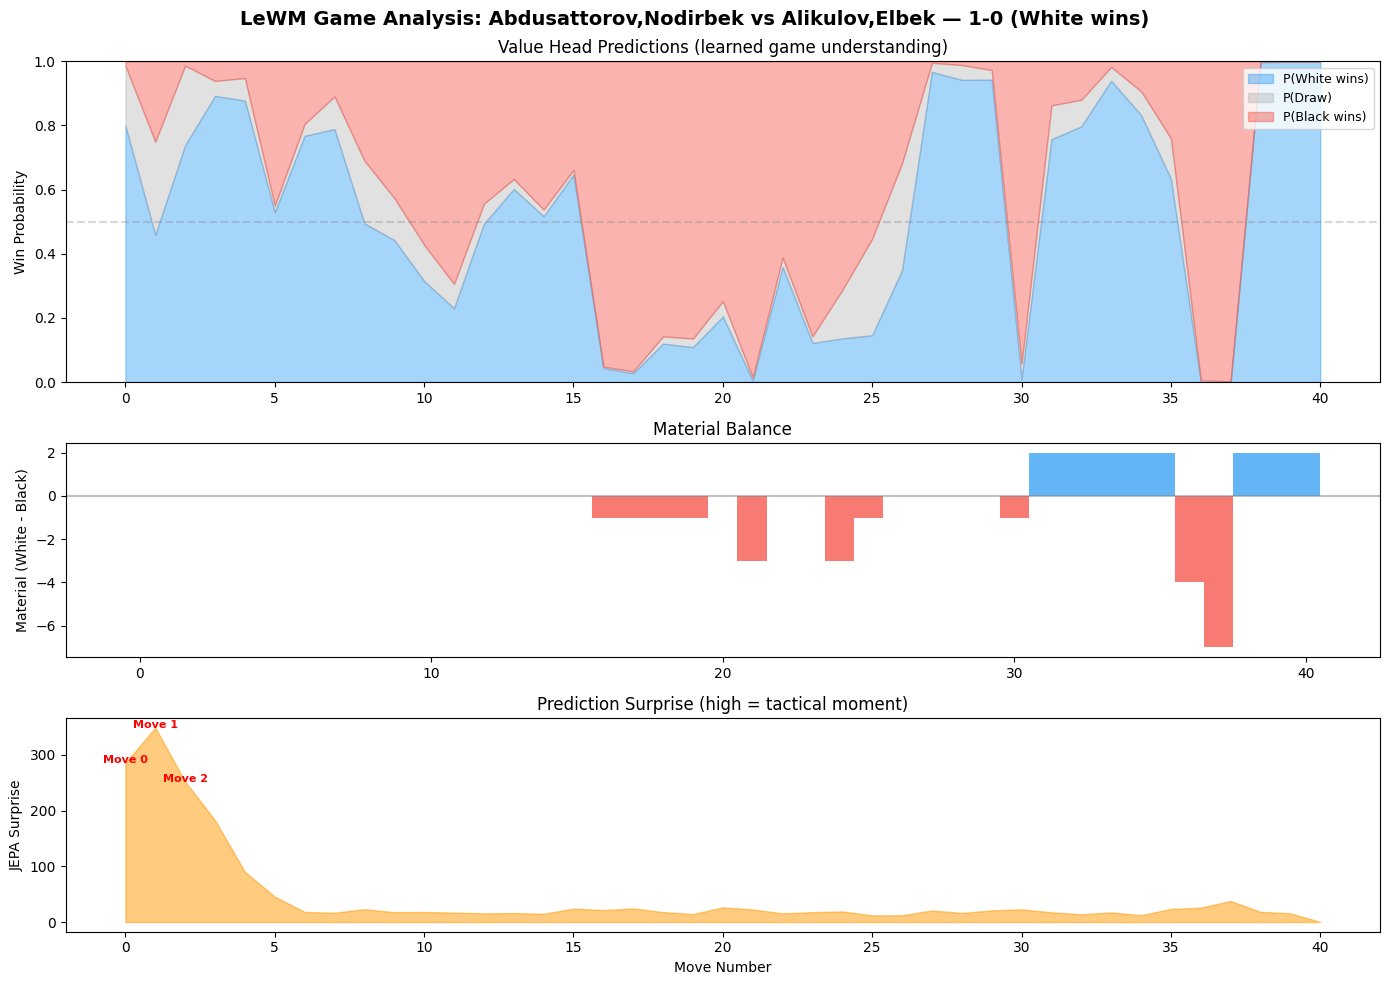

Saved: lewm_game_analysis.png

2/4 — Latent Space Structure...


Encoding for t-SNE: 100%|██████████| 2000/2000 [00:11<00:00, 168.10it/s]


Running t-SNE (this takes ~30s)...


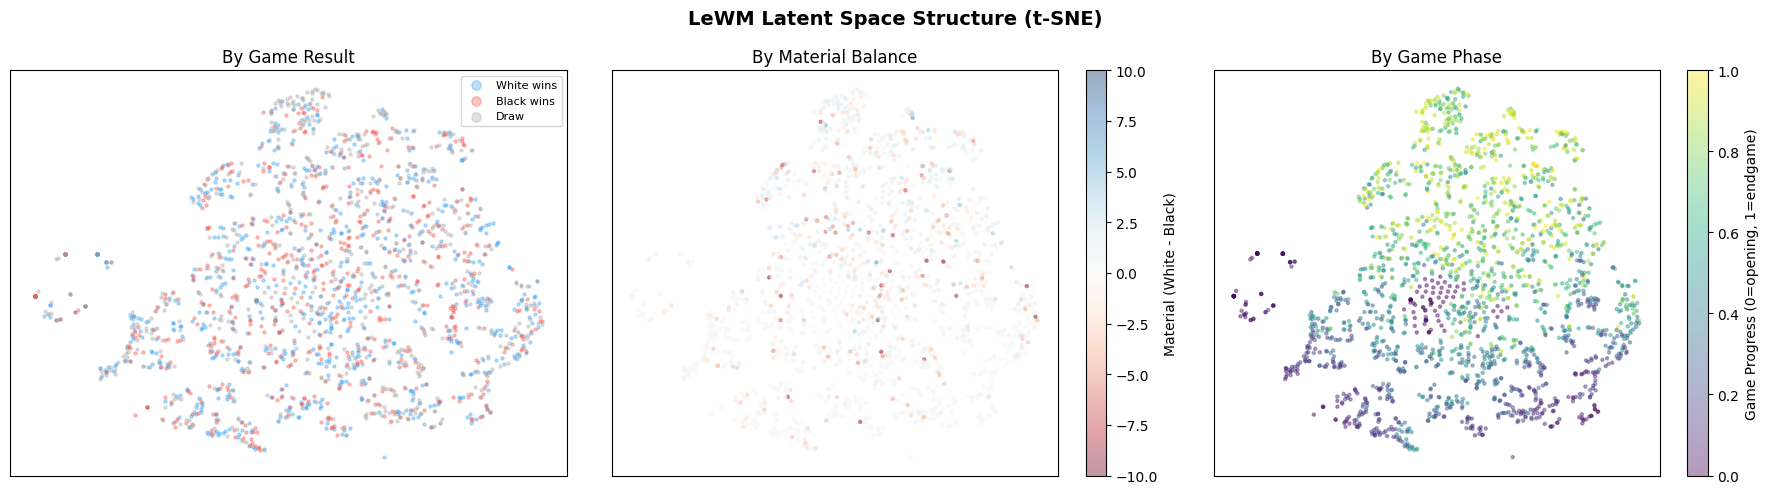

Saved: lewm_latent_space.png

3/4 — Policy Head Analysis...


Policy analysis: 100%|██████████| 500/500 [00:03<00:00, 161.95it/s]


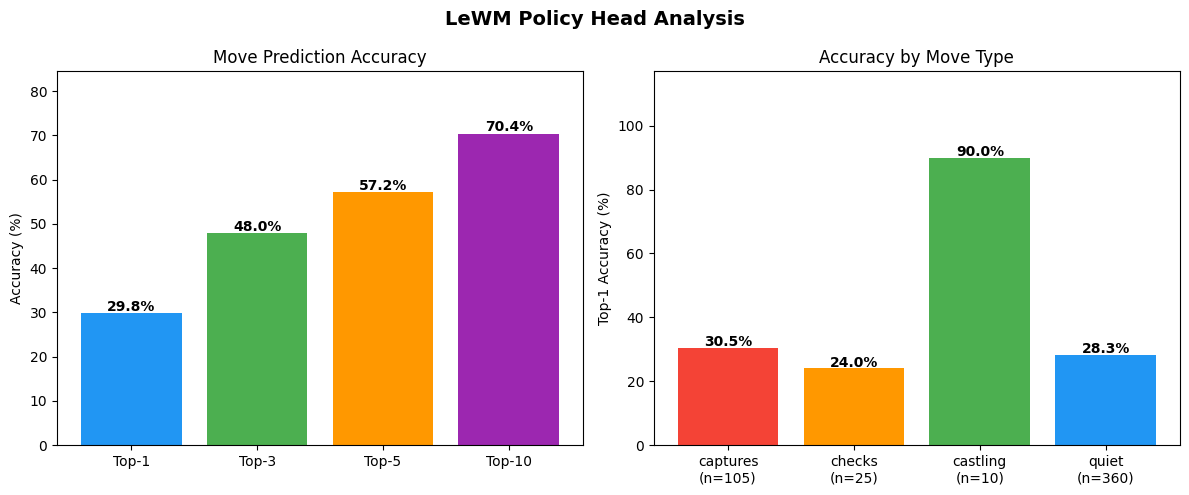

Saved: lewm_policy_analysis.png

4/4 — Value Head Calibration...


Value calibration: 100%|██████████| 2000/2000 [00:12<00:00, 165.26it/s]


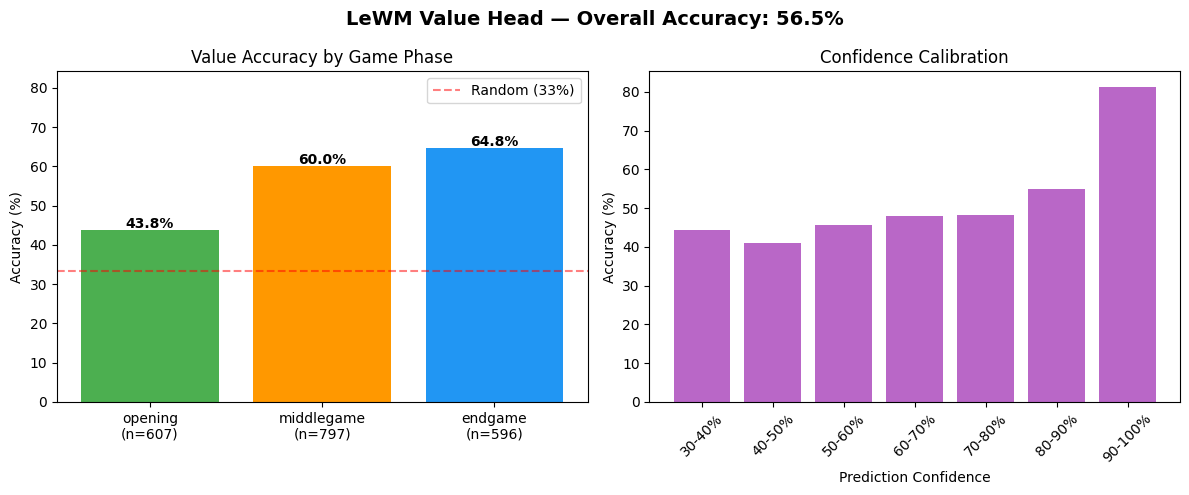

Saved: lewm_value_calibration.png

  Report complete! Files saved:
    • lewm_game_analysis.png
    • lewm_latent_space.png
    • lewm_policy_analysis.png
    • lewm_value_calibration.png


In [19]:
showcase_full_report(model, policy_head, value_head, CFG, CFG.cache_path)